<a href="https://colab.research.google.com/github/MahaR2005/ecommerce_pipeline/blob/main/maha_crime_prediction_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔹 Missing Values BEFORE Cleaning:

                    Missing Values  % Missing
Report Number                    0   0.000000
Date Reported                    0   0.000000
Date of Occurrence               0   0.000000
Time of Occurrence               0   0.000000
City                             0   0.000000
Crime Code                       0   0.000000
Crime Description                0   0.000000
Victim Age                       0   0.000000
Victim Gender                    0   0.000000
Weapon Used                   5790  14.417331
Crime Domain                     0   0.000000
Police Deployed                  0   0.000000
Case Closed                      0   0.000000
Date Case Closed             20098  50.044821
Year                             0   0.000000
Month                            0   0.000000
Day                              0   0.000000
Hour                             0   0.000000
Weapon Risk                      0   0.000000
Crime Severity                   0   0.000000

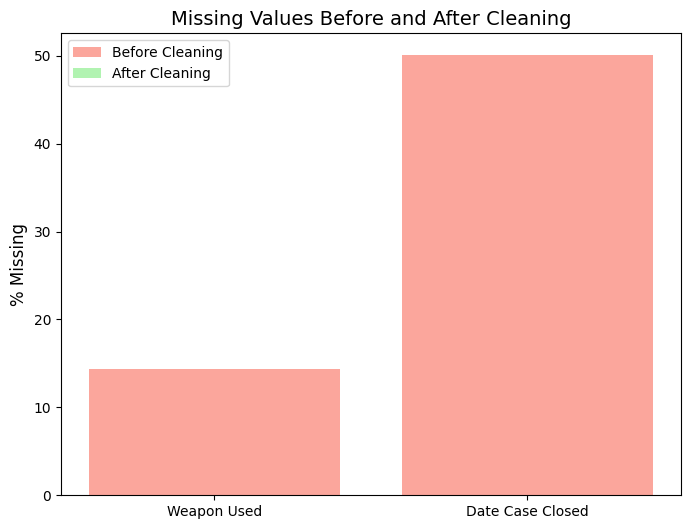

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv("preprocessed_crime_dataset_india.csv", encoding='utf-8')
df = pd.DataFrame(data)


missing_before = df.isna().sum().to_frame('Missing Values')
missing_before['% Missing'] = (df.isna().sum() / len(df)) * 100
print("🔹 Missing Values BEFORE Cleaning:\n")
print(missing_before)


df.columns = df.columns.str.strip()
df['Weapon Used'] = df['Weapon Used'].fillna('Unknown')
df['Date Case Closed'] = df['Date Case Closed'].fillna('Not Closed Yet')


missing_after = df.isna().sum().to_frame('Missing Values')
missing_after['% Missing'] = (df.isna().sum() / len(df)) * 100
print("\n🔹 Missing Values AFTER Cleaning:\n")
print(missing_after)


columns_to_plot = ['Weapon Used', 'Date Case Closed']

plt.figure(figsize=(8, 6))
plt.bar(columns_to_plot, missing_before.loc[columns_to_plot, '% Missing'],
        color='salmon', alpha=0.7, label='Before Cleaning')
plt.bar(columns_to_plot, missing_after.loc[columns_to_plot, '% Missing'],
        color='lightgreen', alpha=0.7, label='After Cleaning')

plt.title("Missing Values Before and After Cleaning", fontsize=14)
plt.ylabel("% Missing", fontsize=12)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import folium
from folium.plugins import HeatMap, MarkerCluster
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


df = pd.read_csv("preprocessed_crime_dataset_india.csv", encoding='utf-8')
df['City'] = df['City'].str.strip().str.title()
print("Cities in data:", df['City'].unique())

df.columns = df.columns.str.strip()
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], format='%d-%m-%Y %H.%M', errors='coerce')
df = df.dropna(subset=['Date of Occurrence'])
df['Year'] = df['Date of Occurrence'].dt.year


grouped = df.groupby(['City', 'Year', 'Crime Description']).size().reset_index(name='Total_Crimes')


predictions = []
for (city, crime), city_data in grouped.groupby(['City', 'Crime Description']):
    if len(city_data) < 2:
        continue
    X = city_data[['Year']]
    y = city_data['Total_Crimes']
    model = LinearRegression()
    model.fit(X, y)
    next_year = city_data['Year'].max() + 1
    predicted = model.predict(pd.DataFrame({'Year': [next_year]}))[0]
    predictions.append([city, crime, int(predicted)])

pred_df = pd.DataFrame(predictions, columns=['City', 'Crime Description', 'Predicted_Crimes_Next_Year'])


city_totals = pred_df.groupby('City')['Predicted_Crimes_Next_Year'].sum().reset_index()
city_coords = {
    'Delhi': [28.7041, 77.1025],
    'Mumbai': [19.0760, 72.8777],
    'Chennai': [13.0827, 80.2707],
    'Kolkata': [22.5726, 88.3639],
    'Bengaluru': [12.9716, 77.5946],
    'Hyderabad': [17.3850, 78.4867],
    'Pune': [18.5204, 73.8567],
    'Ahmedabad': [23.0225, 72.5714],
    'Jaipur': [26.9124, 75.7873],
    'Lucknow': [26.8467, 80.9462],
    'Surat': [21.1702, 72.8311],
    'Patna': [25.5941, 85.1376]
}

city_totals['Latitude'] = city_totals['City'].map(lambda x: city_coords.get(x, [0, 0])[0])
city_totals['Longitude'] = city_totals['City'].map(lambda x: city_coords.get(x, [0, 0])[1])
city_totals = city_totals[(city_totals['Latitude'] != 0)]


current_totals = grouped.groupby('City')['Total_Crimes'].sum().reset_index()
current_totals['Latitude'] = current_totals['City'].map(lambda x: city_coords.get(x, [0, 0])[0])
current_totals['Longitude'] = current_totals['City'].map(lambda x: city_coords.get(x, [0, 0])[1])
current_totals = current_totals[(current_totals['Latitude'] != 0)]


m = folium.Map(location=[22.5, 78.9], zoom_start=5, tiles='cartodb positron')


historical_layer = folium.FeatureGroup(name="Historical Crimes (Blue)").add_to(m)
predicted_layer = folium.FeatureGroup(name="Predicted Crimes (Red)").add_to(m)


for _, row in current_totals.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=max(6, row['Total_Crimes'] / 300),
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.5,
        popup=f"<b>{row['City']} — Historical Crimes</b><br>Total Crimes: {row['Total_Crimes']}"
    ).add_to(historical_layer)

next_year = grouped['Year'].max() + 1
for _, row in city_totals.iterrows():
    crime_details = pred_df[pred_df['City'] == row['City']]
    crime_html = "".join([f"<li>{c}: <b>{v}</b></li>"
                          for c, v in zip(crime_details['Crime Description'], crime_details['Predicted_Crimes_Next_Year'])])
    popup_html = f"""
    <b>{row['City']} — Predicted Crimes for {next_year}</b><br>
    <b>Total Predicted Crimes:</b> {row['Predicted_Crimes_Next_Year']}<br><br>
    <u>Breakdown by Crime Type:</u><br>
    <ul>{crime_html}</ul>
    """
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=max(6, row['Predicted_Crimes_Next_Year'] / 300),
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(predicted_layer)


heat_data = city_totals[['Latitude', 'Longitude', 'Predicted_Crimes_Next_Year']].values.tolist()
HeatMap(heat_data, name="Predicted Crimes Heatmap", radius=25, blur=15).add_to(m)


folium.LayerControl(collapsed=False).add_to(m)


m.save("crime_historical_vs_predicted_map.html")
m

Cities in data: ['Ahmedabad' 'Chennai' 'Ludhiana' 'Pune' 'Delhi' 'Mumbai' 'Surat'
 'Visakhapatnam' 'Bangalore' 'Kolkata' 'Ghaziabad' 'Hyderabad' 'Jaipur'
 'Lucknow' 'Bhopal' 'Patna' 'Kanpur' 'Varanasi' 'Nagpur' 'Meerut' 'Thane'
 'Indore' 'Rajkot' 'Vasai' 'Agra' 'Kalyan' 'Nashik' 'Srinagar' 'Faridabad']


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_true = city_data['Total_Crimes']
y_pred = model.predict(X)

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("MSE:", mse)
print("R² score:", r2)



MSE: 0.2
R² score: 0.9705882352941176


In [ ]:
import pandas as pd
import folium
import numpy as np


df = pd.read_csv("preprocessed_crime_dataset_india.csv", encoding='utf-8')
df['City'] = df['City'].str.strip().str.title()


city_totals = df.groupby('City').size().reset_index(name='Total_Crimes')


city_coords = {
    'Delhi': [28.6139, 77.2090],
    'Mumbai': [19.0760, 72.8777],
    'Bangalore': [12.9716, 77.5946],
    'Chennai': [13.0827, 80.2707],
    'Kolkata': [22.5726, 88.3639],
    'Pune': [18.5204, 73.8567],
    'Hyderabad': [17.3850, 78.4867],
    'Jaipur': [26.9124, 75.7873],
    'Lucknow': [26.8467, 80.9462],
    'Ahmedabad': [23.0225, 72.5714],
    'Patna': [25.5941, 85.1376],
    'Surat': [21.1702, 72.8311]
}


low_thresh = city_totals['Total_Crimes'].quantile(0.33)
mid_thresh = city_totals['Total_Crimes'].quantile(0.66)

def safety_info(score):
    if score <= low_thresh:
        return "🟢 Safe — Can go alone or at night.", "green", "check"
    elif score <= mid_thresh:
        return "🟠 Moderate — Be cautious, especially at night.", "orange", "info-sign"
    else:
        return "🔴 Unsafe — Avoid going alone or traveling late night.", "red", "exclamation-sign"


min_radius = 5
max_radius = 15
scores = city_totals['Total_Crimes']
city_totals['Radius'] = min_radius + (scores - scores.min()) / (scores.max() - scores.min()) * (max_radius - min_radius)


m = folium.Map(location=[22.9734, 78.6569], zoom_start=5, tiles="CartoDB positron")

for _, row in city_totals.iterrows():
    city = row['City']
    score = row['Total_Crimes']
    radius = row['Radius']
    if city in city_coords:
        message, color, icon = safety_info(score)

        folium.CircleMarker(
            location=city_coords[city],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.3
        ).add_to(m)

        folium.Marker(
            location=city_coords[city],
            popup=f"<b>{city}</b><br>{message}<br>Total Crimes: {score}",
            tooltip=f"{city}: {score}",
            icon=folium.Icon(color=color, icon=icon)
        ).add_to(m)

m.save("crime_safety_dataset_map_scaled.html")
m


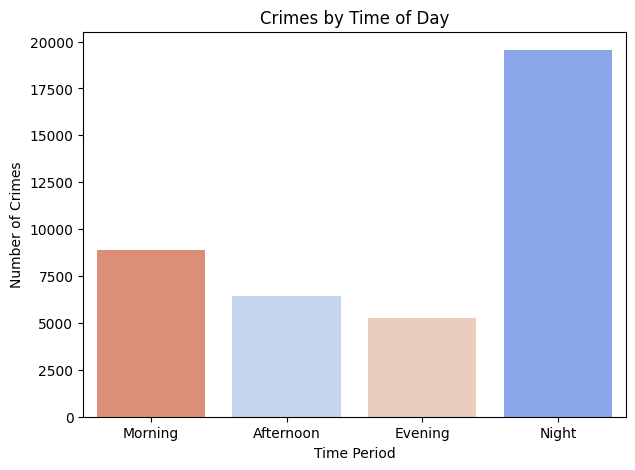

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re


df['Hour'] = df['Time of Occurrence'].astype(str).apply(lambda x: float(re.findall(r'\d+', x)[0]) if re.findall(r'\d+', x) else None)


def get_time_period(hour):
    if pd.isna(hour):
        return 'Unknown'
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time Period'] = df['Hour'].apply(get_time_period)


plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Time Period', order=['Morning', 'Afternoon', 'Evening', 'Night'], hue='Time Period', legend=False, palette='coolwarm')
plt.title('Crimes by Time of Day')
plt.xlabel('Time Period')
plt.ylabel('Number of Crimes')
plt.show()


In [ ]:
import plotly.express as px

fig = px.sunburst(
    df,
    path=['City', 'Crime Description', 'Victim Gender'],
    values=None,
    color='City',
    color_discrete_sequence=px.colors.sequential.Reds,
    title="Crime Distribution by City, Type, and Victim Gender"
)
fig.show()



✅ Model Accuracy: 50.71%

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.03      0.05       765
           1       0.57      0.79      0.66      4590
           2       0.04      0.01      0.02       383
           3       0.29      0.18      0.22      2294

    accuracy                           0.51      8032
   macro avg       0.26      0.25      0.24      8032
weighted avg       0.43      0.51      0.45      8032



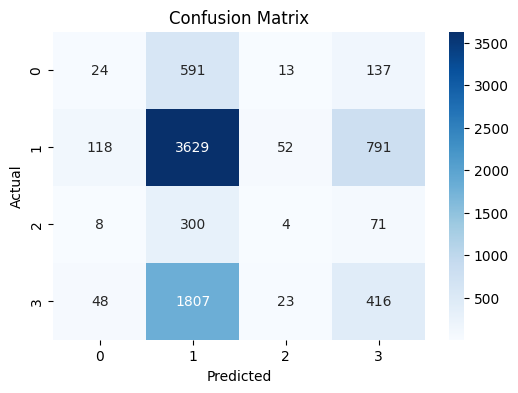

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


X = df[['City', 'Victim Age', 'Victim Gender', 'Weapon Used',
        'Police Deployed', 'Case Closed']].copy()
y = df['Crime Domain']


le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
